# Geo Fire: Previsão de Risco de Queimadas com Dados Climáticos

**Global Solution FIAP 2026.1 | Economia Espacial**

Este notebook treina um modelo de classificação de risco de incêndio baseado em
condições climáticas históricas (temperatura, umidade, vento, precipitação) obtidas
via OpenMeteo, correlacionadas com focos de queimada detectados por satélite (NASA FIRMS).

**Fluxo:**
1. Dados [FIRMS](https://firms.modaps.eosdis.nasa.gov/) (focos de incêndio) + [OpenMeteo](https://open-meteo.com/) (clima histórico) → dataset enriquecido
2. EDA: análise das relações entre clima e intensidade de queimadas
3. ML: RandomForestClassifier prevê risco (baixo/médio/alto) a partir de variáveis climáticas
4. Dashboard: uso em tempo real com dados atuais do OpenMeteo + sensores IoT

**Grupo:**
- Heitor Exposito de Sousa, RM 566013
- Marco Antonio Rodrigues Siqueira, RM 569975
- Nadia Nakamura Vieira, RM 568906
- Rafael Bassani, RM 569930
- Vinicius Xavier da Silva, RM 572108

---

## Etapas do notebook

1. **Setup**: importação de bibliotecas e configuração
2. **Carregamento**: leitura do dataset FIRMS + clima
3. **EDA**: análise exploratória com foco em variáveis climáticas
4. **Feature Engineering**: preparação dos dados para ML
5. **RandomForest**: treinamento e avaliação do classificador
6. **Exportação**: salvando o modelo treinado
7. **Predição**: teste com amostras reais

In [42]:
# ============================================================
# Setup — Bibliotecas e configurações
# ============================================================
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Configuração de estilo
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
})
sns.set_style("whitegrid")

print("\n".join([
    f"pandas      : {pd.__version__}",
    f"numpy       : {np.__version__}",
    f"sklearn     : {__import__('sklearn').__version__}",
    f"matplotlib  : {plt.matplotlib.__version__}",
    f"seaborn     : {sns.__version__}",
    f"joblib      : {joblib.__version__}",
]))

pandas      : 3.0.3
numpy       : 2.4.6
sklearn     : 1.9.0
matplotlib  : 3.10.9
seaborn     : 0.13.2
joblib      : 1.5.3


## 1. Carregamento dos dados

O dataset combina:
- **NASA FIRMS**: focos de incêndio detectados por satélite (VIIRS S-NPP, VIIRS NOAA-20, MODIS)
- **OpenMeteo**: clima histórico para cada local de foco (temperatura, umidade, vento, precipitação)

O dataset enriquecido (`firms_com_clima.csv`) foi gerado pelo script `collect_weather.py`.
Caso não exista, o notebook carrega apenas os dados FIRMS brutos.

In [43]:
from pathlib import Path

# Tentar carregar dataset enriquecido; se não existir, usar FIRMS bruto
candidates_enriched = [
    Path("data/firms_com_clima.csv"),
    Path("../../data/firms_com_clima.csv"),
    Path("../data/firms_com_clima.csv"),
]
candidates_raw = [
    Path("data/firms_brasil.csv"),
    Path("../../data/firms_brasil.csv"),
    Path("../data/firms_brasil.csv"),
]

DATA_PATH = next((p for p in candidates_enriched if p.exists()), None)
USING_ENRICHED = DATA_PATH is not None

if not USING_ENRICHED:
    DATA_PATH = next((p for p in candidates_raw if p.exists()), candidates_raw[0])
    print("⚠️  Dataset enriquecido não encontrado. Usando FIRMS bruto.")
    print("   Execute 'python src/python/collect_weather.py' para gerar dados climáticos.")
else:
    print(f"✅ Dataset enriquecido carregado: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"\nShape: {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")

# Mostrar apenas colunas relevantes
key_cols = ["latitude", "longitude", "acq_date", "satellite", "frp", "confidence"]
weather_cols_available = [c for c in ["temp_max", "temp_min", "temp_mean",
                                       "humidity", "wind_speed", "precipitation",
                                       "soil_moisture"] if c in df.columns]

print(f"\nColunas climáticas disponíveis: {weather_cols_available}")
print(f"\nPrimeiras 5 linhas:")
from IPython.display import display as _display
try:
    _display(df[key_cols + weather_cols_available].head())
except NameError:
    print(df[key_cols + weather_cols_available].head())

print(f"\nInformações do dataset:")
df.info()

✅ Dataset enriquecido carregado: ../../data/firms_com_clima.csv

Shape: 2074 linhas, 21 colunas

Colunas: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'temp_max', 'temp_min', 'temp_mean', 'wind_speed', 'precipitation', 'humidity', 'soil_moisture']

Colunas climáticas disponíveis: ['temp_max', 'temp_min', 'temp_mean', 'humidity', 'wind_speed', 'precipitation', 'soil_moisture']

Primeiras 5 linhas:


,latitude,longitude,acq_date,satellite,frp,confidence,temp_max,temp_min,temp_mean,humidity,wind_speed,precipitation,soil_moisture
0,-6.98311,-42.88001,2026-06-08,N,2.73,n,34.4,24.4,29.6,46.958333,25.4,0.0,0.062000
1,-6.98186,-42.88663,2026-06-08,N,2.73,n,34.4,24.4,29.6,46.958333,25.4,0.0,0.062000
2,-6.98017,-42.87912,2026-06-08,N,4.15,n,34.4,24.4,29.6,46.958333,25.4,0.0,0.062000
3,-6.97889,-42.88566,2026-06-08,N,7.41,n,34.4,24.4,29.6,46.958333,25.4,0.0,0.062000
4,-5.51961,-37.48548,2026-06-08,N,1.11,n,31.8,22.9,27.2,66.458333,20.8,0.0,0.189958



Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2074 entries, 0 to 2073
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   latitude       2074 non-null   float64
 1   longitude      2074 non-null   float64
 2   bright_ti4     2074 non-null   float64
 3   scan           2074 non-null   float64
 4   track          2074 non-null   float64
 5   acq_date       2074 non-null   str    
 6   acq_time       2074 non-null   int64  
 7   satellite      2074 non-null   str    
 8   instrument     2074 non-null   str    
 9   confidence     2074 non-null   str    
 10  version        2074 non-null   str    
 11  bright_ti5     2074 non-null   float64
 12  frp            2074 non-null   float64
 13  daynight       2074 non-null   str    
 14  temp_max       2074 non-null   float64
 15  temp_min       2074 non-null   float64
 16  temp_mean      2074 non-null   float64
 17  wind_speed     2074 non-null   float64

## 2. Análise exploratória (EDA)

Aqui a gente olha como as variáveis climáticas se comportam nos dados
e se existe relação com a intensidade dos focos detectados pelo satélite.

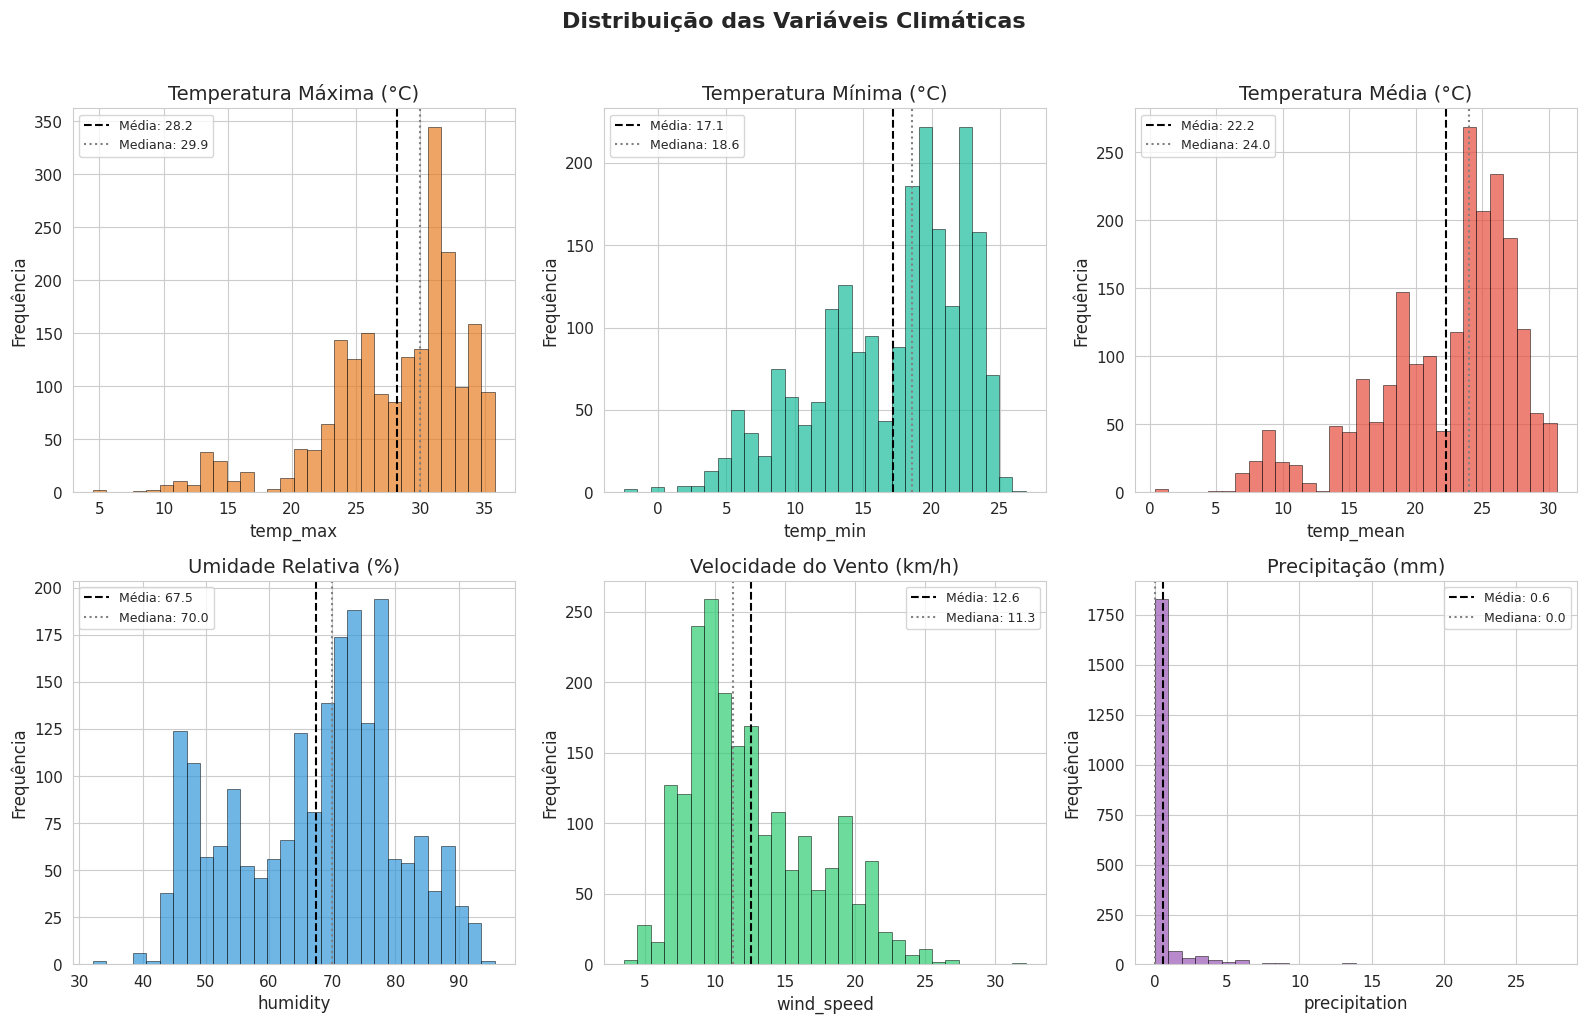

In [44]:
# ============================================================
# 2.1 Distribuição de variáveis climáticas
# ============================================================
if weather_cols_available:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    plot_data = {
        "temp_mean": ("Temperatura Média (°C)", "#E74C3C"),
        "humidity": ("Umidade Relativa (%)", "#3498DB"),
        "wind_speed": ("Velocidade do Vento (km/h)", "#2ECC71"),
        "precipitation": ("Precipitação (mm)", "#9B59B6"),
        "temp_max": ("Temperatura Máxima (°C)", "#E67E22"),
        "temp_min": ("Temperatura Mínima (°C)", "#1ABC9C"),
    }

    for i, col in enumerate(weather_cols_available[:6]):
        if col in plot_data:
            label, color = plot_data[col]
            ax = axes[i]
            data = df[col].dropna()
            ax.hist(data, bins=30, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
            ax.axvline(data.mean(), color="black", ls="--", lw=1.5,
                       label=f"Média: {data.mean():.1f}")
            ax.axvline(data.median(), color="gray", ls=":", lw=1.5,
                       label=f"Mediana: {data.median():.1f}")
            ax.set_title(label)
            ax.set_xlabel(col)
            ax.set_ylabel("Frequência")
            ax.legend(fontsize=9)

    # Esconder eixos não utilizados
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Distribuição das Variáveis Climáticas", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Dados climáticos não disponíveis. Execute collect_weather.py primeiro.")

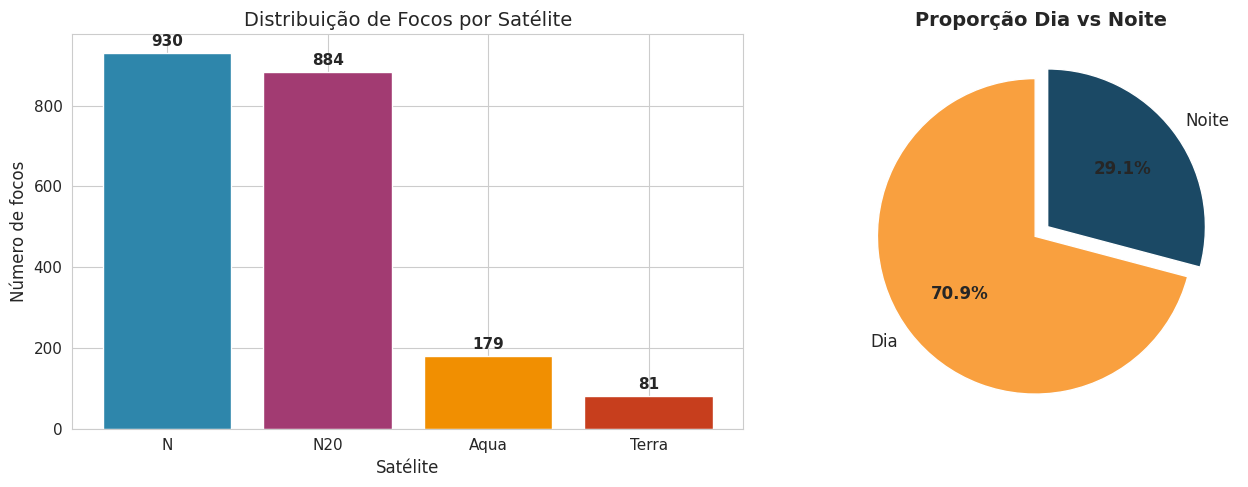

Satélite mais frequente: N (930 focos)
Focos noturnos: 604 | Focos diurnos: 1470


In [45]:
# ============================================================
# 2.2 Distribuição por satélite e dia/noite
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Satélite
sat_counts = df["satellite"].value_counts()
ax = axes[0]
bars = ax.bar(sat_counts.index, sat_counts.values, color=["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"])
ax.set_title("Distribuição de Focos por Satélite")
ax.set_xlabel("Satélite")
ax.set_ylabel("Número de focos")
for bar, val in zip(bars, sat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            str(val), ha="center", va="bottom", fontweight="bold")

# Dia/Noite
dn_counts = df["daynight"].value_counts()
labels_dn = {"D": "Dia", "N": "Noite"}
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    dn_counts.values,
    labels=[labels_dn[k] for k in dn_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#F9A03F", "#1B4965"],
    explode=(0.05, 0.05),
    textprops={"fontsize": 12},
)
for t in autotexts:
    t.set_fontweight("bold")
ax.set_title("Proporção Dia vs Noite", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Satélite mais frequente: {sat_counts.index[0]} ({sat_counts.values[0]} focos)")
print(f"Focos noturnos: {dn_counts.get('N', 0)} | Focos diurnos: {dn_counts.get('D', 0)}")

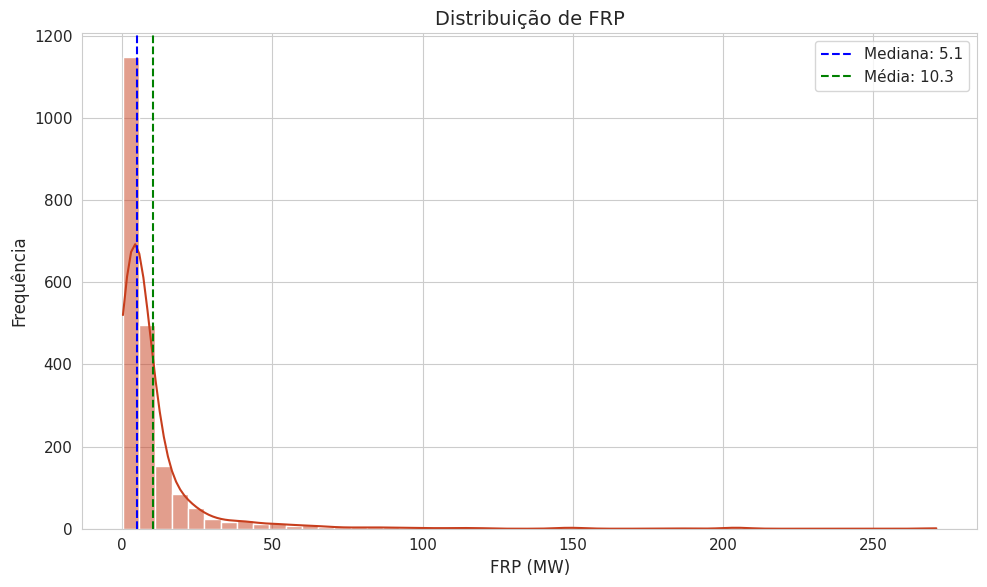

FRP médio: 10.31 MW | Mediana: 5.07 MW | Máximo: 271.05 MW


In [46]:
# ============================================================
# 2.3 Distribuição de FRP
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df["frp"], bins=50, kde=True, ax=ax, color="#C73E1D")
ax.set_title("Distribuição de FRP")
ax.set_xlabel("FRP (MW)")
ax.set_ylabel("Frequência")
ax.axvline(df["frp"].median(), color="blue", ls="--",
           label=f"Mediana: {df['frp'].median():.1f}")
ax.axvline(df["frp"].mean(), color="green", ls="--",
           label=f"Média: {df['frp'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"FRP médio: {df['frp'].mean():.2f} MW | Mediana: {df['frp'].median():.2f} MW | Máximo: {df['frp'].max():.2f} MW")

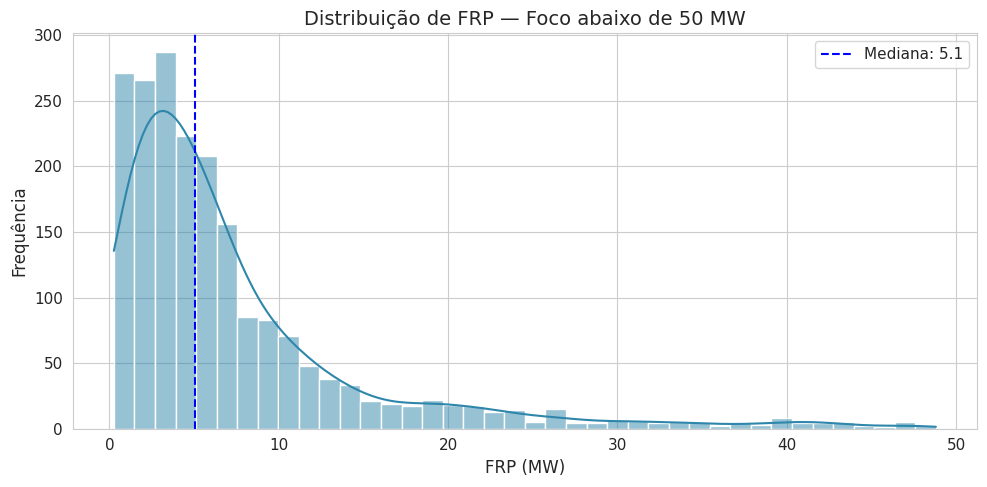

Focos com FRP >= 50 MW: 69 (3.3%)
Esses poucos registros com FRP muito alto comprimem o histograma anterior.
A cauda longa vai até 271 MW, mas a mediana é de apenas 5.1 MW.


In [47]:
# Zoom na cauda principal (FRP < 50 MW)
# A maioria dos focos se concentra aqui; os poucos acima de 50 MW
# comprimem o eixo x e escondem o padrão.
mask = df["frp"] < 50
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df.loc[mask, "frp"], bins=40, kde=True, ax=ax, color="#2E86AB")
ax.set_title("Distribuição de FRP — Foco abaixo de 50 MW")
ax.set_xlabel("FRP (MW)")
ax.set_ylabel("Frequência")
ax.axvline(df["frp"].median(), color="blue", ls="--",
           label=f"Mediana: {df['frp'].median():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

# Quantificação da cauda longa
n_alto = (df["frp"] >= 50).sum()
print(f"Focos com FRP >= 50 MW: {n_alto} ({n_alto / len(df) * 100:.1f}%)")
print("Esses poucos registros com FRP muito alto comprimem o histograma anterior.")
print("A cauda longa vai até 271 MW, mas a mediana é de apenas", f"{df['frp'].median():.1f} MW.")

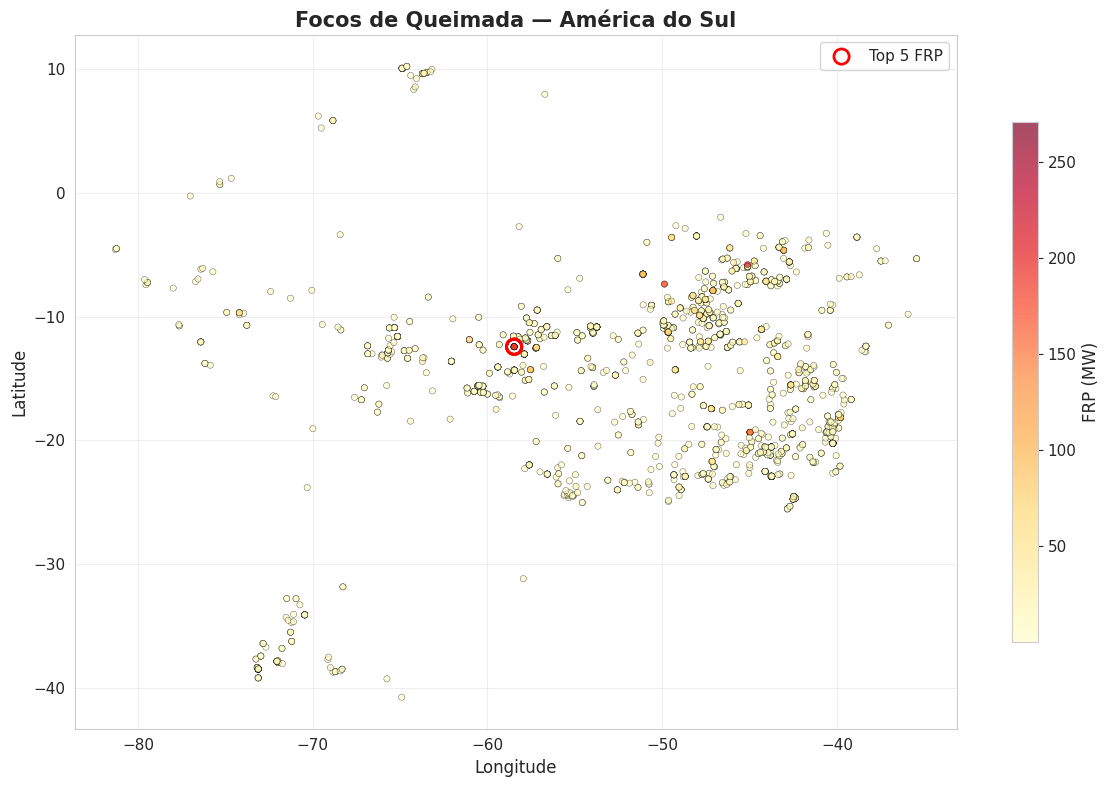

In [48]:
# ============================================================
# 2.4 Mapa de focos
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["frp"], cmap="YlOrRd", alpha=0.7,
    s=20, edgecolors="k", linewidth=0.3,
)
plt.colorbar(sc, ax=ax, label="FRP (MW)", shrink=0.75)
ax.set_title("Focos de Queimada — América do Sul", fontsize=15, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

top5 = df.nlargest(5, "frp")
ax.scatter(top5["longitude"], top5["latitude"], s=120, facecolors="none",
           edgecolors="red", linewidths=2, label="Top 5 FRP")
ax.legend()

plt.tight_layout()
plt.show()

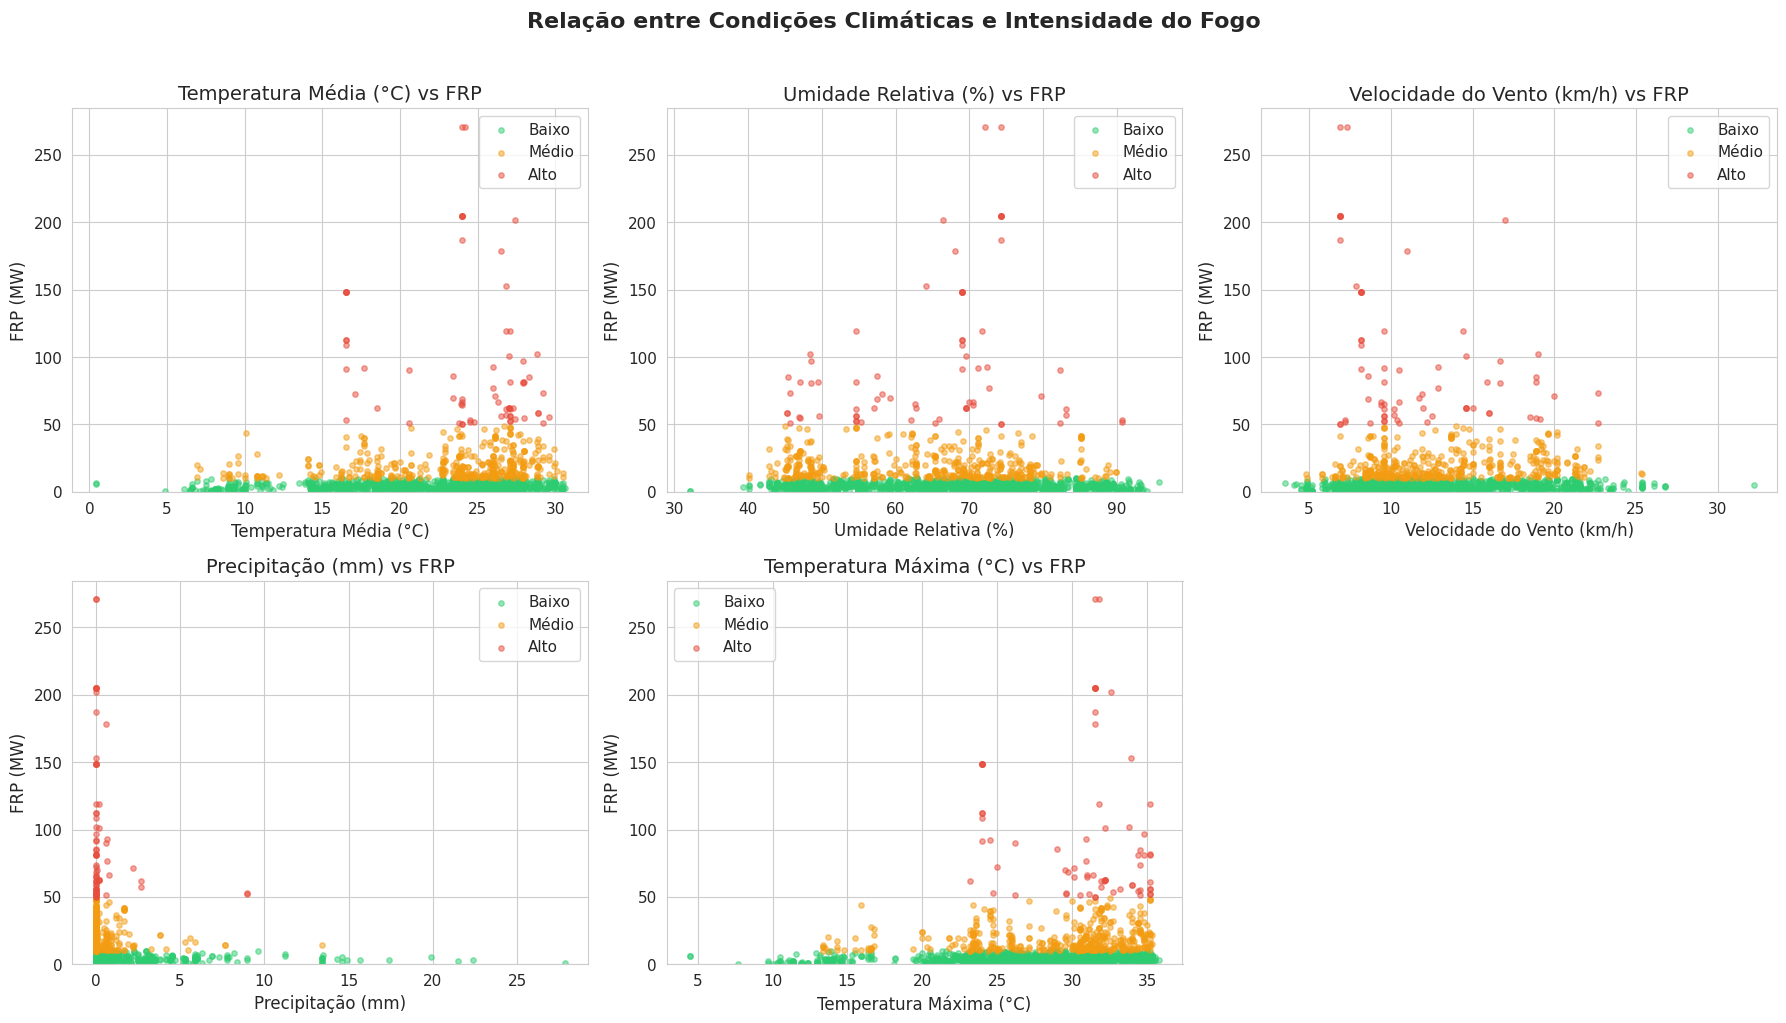

In [49]:
# ============================================================
# 2.5 Scatter plots: variáveis climáticas vs FRP
# ============================================================
if weather_cols_available:
    # Classificar risco para colorir os pontos
    def _risk(frp):
        if frp < 10:
            return "Baixo"
        elif frp < 50:
            return "Médio"
        return "Alto"

    df["_risk_label"] = df["frp"].apply(_risk)
    risk_colors = {"Baixo": "#2ECC71", "Médio": "#F39C12", "Alto": "#E74C3C"}

    scatter_vars = [c for c in ["temp_mean", "humidity", "wind_speed",
                                 "precipitation", "temp_max"] if c in df.columns]

    if scatter_vars:
        n = len(scatter_vars)
        ncols = 3
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
        axes = np.array(axes).flatten() if n > 1 else [axes]

        labels_map = {
            "temp_mean": "Temperatura Média (°C)",
            "temp_max": "Temperatura Máxima (°C)",
            "humidity": "Umidade Relativa (%)",
            "wind_speed": "Velocidade do Vento (km/h)",
            "precipitation": "Precipitação (mm)",
        }

        for i, col in enumerate(scatter_vars):
            ax = axes[i]
            for risk in ["Baixo", "Médio", "Alto"]:
                mask = df["_risk_label"] == risk
                ax.scatter(df.loc[mask, col], df.loc[mask, "frp"],
                           alpha=0.5, s=15, label=risk, color=risk_colors[risk])
            ax.set_xlabel(labels_map.get(col, col))
            ax.set_ylabel("FRP (MW)")
            ax.set_title(f"{labels_map.get(col, col)} vs FRP")
            ax.legend()
            ax.set_ylim(bottom=0)

        # Esconder eixos extras
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle("Relação entre Condições Climáticas e Intensidade do Fogo",
                      fontsize=16, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    df = df.drop(columns=["_risk_label"])

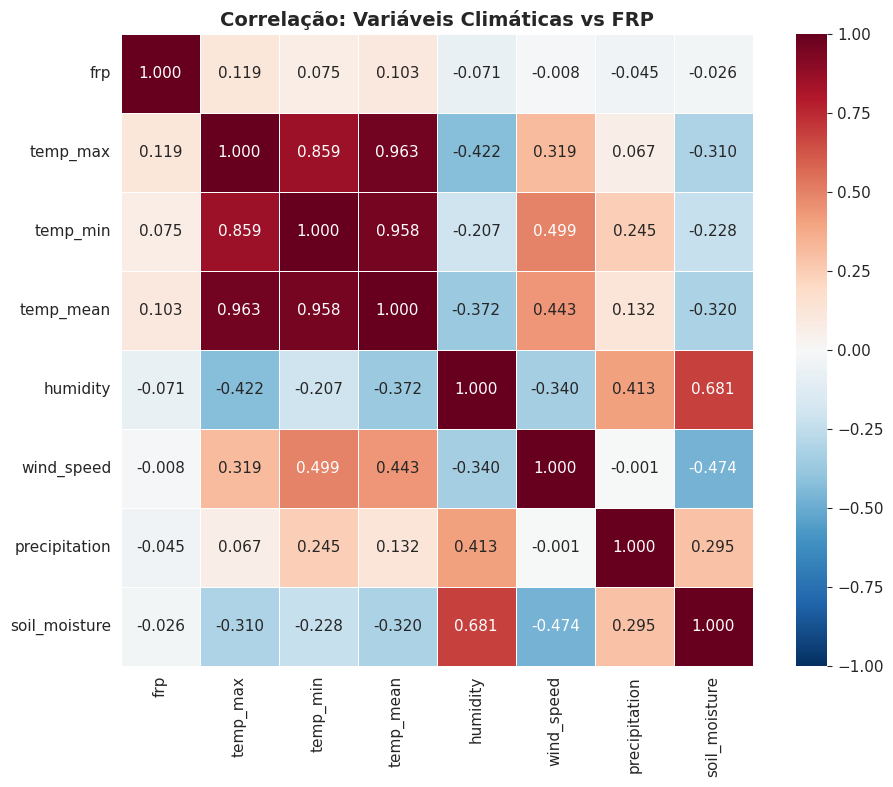

Correlação com FRP:
              temp_max: +0.119
              temp_min: +0.075
             temp_mean: +0.103
              humidity: -0.071
            wind_speed: -0.008
         precipitation: -0.045
         soil_moisture: -0.026


In [50]:
# ============================================================
# 2.6 Heatmap de correlação
# ============================================================
if weather_cols_available:
    corr_cols = ["frp"] + [c for c in weather_cols_available if c in df.columns]
    corr_matrix = df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr_matrix, annot=True, fmt=".3f", cmap="RdBu_r",
        center=0, vmin=-1, vmax=1, ax=ax,
        square=True, linewidths=0.5,
    )
    ax.set_title("Correlação: Variáveis Climáticas vs FRP", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("Correlação com FRP:")
    for col in corr_cols[1:]:
        r = corr_matrix.loc[col, "frp"]
        print(f"  {col:>20}: {r:+.3f}")

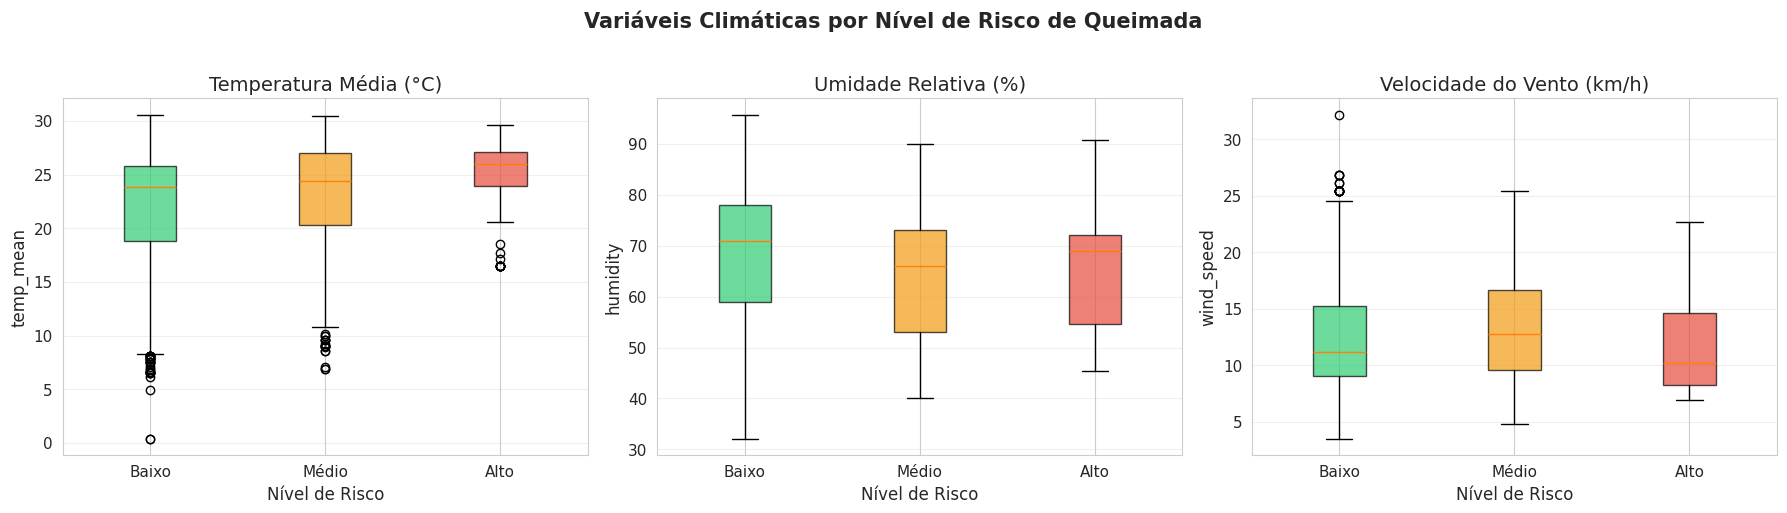

In [51]:
# ============================================================
# 2.7 Boxplot: variáveis climáticas por nível de risco
# ============================================================
if weather_cols_available:
    def classify_risk(frp):
        if frp < 10:
            return "Baixo"
        elif frp < 50:
            return "Médio"
        return "Alto"

    df["_risk"] = df["frp"].apply(classify_risk)
    risk_order = ["Baixo", "Médio", "Alto"]
    box_vars = [c for c in ["temp_mean", "humidity", "wind_speed"] if c in df.columns]

    if box_vars:
        fig, axes = plt.subplots(1, len(box_vars), figsize=(6 * len(box_vars), 5))
        if len(box_vars) == 1:
            axes = [axes]

        labels_map = {
            "temp_mean": "Temperatura Média (°C)",
            "humidity": "Umidade Relativa (%)",
            "wind_speed": "Velocidade do Vento (km/h)",
        }

        colors_risk = ["#2ECC71", "#F39C12", "#E74C3C"]

        for i, col in enumerate(box_vars):
            ax = axes[i]
            data_to_plot = [
                df.loc[df["_risk"] == r, col].dropna().values
                for r in risk_order
            ]
            bp = ax.boxplot(data_to_plot, labels=risk_order, patch_artist=True)
            for patch, color in zip(bp["boxes"], colors_risk):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            ax.set_title(labels_map.get(col, col))
            ax.set_xlabel("Nível de Risco")
            ax.set_ylabel(col)
            ax.grid(axis="y", alpha=0.3)

        plt.suptitle("Variáveis Climáticas por Nível de Risco de Queimada",
                      fontsize=15, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    df = df.drop(columns=["_risk"])

## 3. Feature Engineering

### Variável alvo (`risk`)

Classificação de risco baseada no FRP (Fire Radiative Power):

| Risco | FRP (MW) | Descrição |
|-------|----------|-----------|
| **Baixo** | < 10 | Queimadas de baixa intensidade |
| **Médio** | 10 a 50 | Queimadas de média intensidade |
| **Alto** | >= 50 | Queimadas severas |

### Features selecionadas

O modelo usa **condições climáticas** como features (não dados do satélite):

- `temp_max`: temperatura máxima do ar (°C)
- `temp_min`: temperatura mínima do ar (°C)
- `temp_mean`: temperatura média do ar (°C)
- `humidity`: umidade relativa média (%)
- `wind_speed`: velocidade máxima do vento (km/h)
- `precipitation`: precipitação acumulada (mm)
- `soil_moisture`: umidade do solo (m³/m³)
- `satellite`: satélite detectado (one-hot encoded)
- `daynight`: detecção diurna/noturna (one-hot encoded)

**Nota:** FRP e bright_ti4/5 NÃO são usadas como features para evitar circularidade
(o risco é definido a partir do FRP). O mês (`month`) também é excluído porque o
dataset contém apenas um dia de dados, tornando essa feature constante.

In [52]:
# ============================================================
# Criação da variável alvo
# ============================================================
def classify_risk(frp):
    if frp < 10:
        return "baixo"
    elif frp < 50:
        return "medio"
    else:
        return "alto"

df["risk"] = df["frp"].apply(classify_risk)
risk_map = {"baixo": 0, "medio": 1, "alto": 2}
df["risk_encoded"] = df["risk"].map(risk_map)

print("Distribuição das classes de risco:")
print(df["risk"].value_counts().to_frame())
print()
print("Proporção:")
print(df["risk"].value_counts(normalize=True).mul(100).round(1).astype(str).add("%").to_frame())

# ============================================================
# Preparação das features
# ============================================================
# Features climáticas (principal)
climate_features = [c for c in ["temp_max", "temp_min", "temp_mean",
                                 "humidity", "wind_speed", "precipitation",
                                 "soil_moisture"] if c in df.columns]

# One-hot encoding para variáveis categóricas
cat_features = pd.get_dummies(df[["satellite", "daynight"]], drop_first=True, dtype=int)

# Combinar todas as features
X = pd.concat([df[climate_features], cat_features], axis=1)
y = df["risk_encoded"]

# Remover linhas com NaN nas features climáticas
if climate_features:
    mask = X[climate_features].notna().all(axis=1)
    n_before = len(X)
    X = X[mask]
    y = y[mask]
    df_clean = df[mask]
    n_removed = n_before - len(X)
    if n_removed > 0:
        print(f"\n⚠️ Removidas {n_removed} linhas com dados climáticos faltantes.")
        print(f"   Amostras restantes: {len(X)}")

print(f"\nFeatures finais ({X.shape[1]} colunas):")
print(list(X.columns))
print(f"\nTotal de amostras: {len(X)}")
print(f"Total de features: {X.shape[1]}")

# ============================================================
# Train/Test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTreino: {len(X_train)} amostras")
print(f"Teste:  {len(X_test)} amostras")
print(f"\nDistribuição em treino:")
print(y_train.value_counts().to_frame())
print(f"\nDistribuição em teste:")
print(y_test.value_counts().to_frame())

Distribuição das classes de risco:
       count
risk        
baixo   1581
medio    424
alto      69

Proporção:
      proportion
risk            
baixo      76.2%
medio      20.4%
alto        3.3%

Features finais (11 colunas):
['temp_max', 'temp_min', 'temp_mean', 'humidity', 'wind_speed', 'precipitation', 'soil_moisture', 'satellite_N', 'satellite_N20', 'satellite_Terra', 'daynight_N']

Total de amostras: 2074
Total de features: 11

Treino: 1659 amostras
Teste:  415 amostras

Distribuição em treino:
              count
risk_encoded       
0              1265
1               339
2                55

Distribuição em teste:
              count
risk_encoded       
0               316
1                85
2                14


## 4. Treinamento: Random Forest

O **Random Forest** é um ensemble de árvores de decisão. Lida bem com outliers,
captura relações não lineares e permite medir a importância de cada feature.

**Hiperparâmetros:**
- `n_estimators=100`: 100 árvores
- `random_state=42`: reprodutibilidade
- Demais parâmetros com valores padrão do scikit-learn

✅ Acurácia: 0.8410 (84.10%)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   baixo (0)       0.88      0.94      0.91       316
   medio (1)       0.66      0.52      0.58        85
    alto (2)       0.88      0.50      0.64        14

    accuracy                           0.84       415
   macro avg       0.80      0.65      0.71       415
weighted avg       0.83      0.84      0.83       415



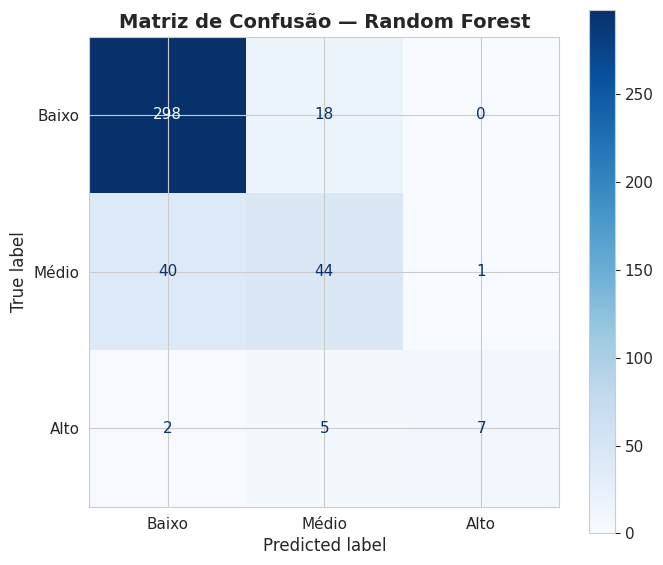

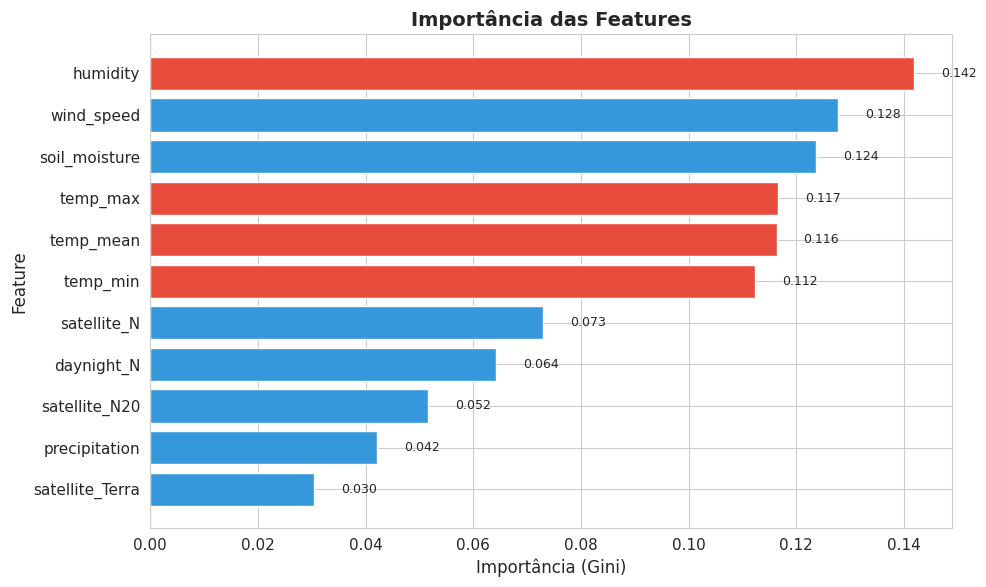


Ranking de importância das features:
  1. humidity: 0.1419
  2. wind_speed: 0.1278
  3. soil_moisture: 0.1237
  4. temp_max: 0.1166
  5. temp_mean: 0.1163
  6. temp_min: 0.1123
  7. satellite_N: 0.0730
  8. daynight_N: 0.0643
  9. satellite_N20: 0.0516
  10. precipitation: 0.0421
  11. satellite_Terra: 0.0304


In [53]:
# ============================================================
# Treinamento
# ============================================================
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# ============================================================
# Métricas
# ============================================================
acc = accuracy_score(y_test, y_pred)
print(f"✅ Acurácia: {acc:.4f} ({acc * 100:.2f}%)\n")

print("=" * 65)
print("CLASSIFICATION REPORT")
print("=" * 65)
print(classification_report(
    y_test, y_pred,
    target_names=["baixo (0)", "medio (1)", "alto (2)"],
    zero_division=0,
))

# ============================================================
# Matriz de confusão
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Baixo", "Médio", "Alto"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Matriz de Confusão — Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ============================================================
# Feature Importance
# ============================================================
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E74C3C" if f in ["temp_mean", "temp_max", "temp_min", "humidity"]
          else "#3498DB" for f in importances["feature"]]
bars = ax.barh(importances["feature"], importances["importance"], color=colors)
ax.set_title("Importância das Features", fontsize=14, fontweight="bold")
ax.set_xlabel("Importância (Gini)")
ax.set_ylabel("Feature")

for bar, val in zip(bars, importances["importance"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", ha="left", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nRanking de importância das features:")
for i, (_, row) in enumerate(importances[::-1].iterrows(), 1):
    print(f"  {i}. {row['feature']}: {row['importance']:.4f}")

## 5. Exportação do modelo

Salvamos o modelo treinado com `joblib`. O dashboard Streamlit carrega esse
arquivo e o combina com dados climáticos atuais do OpenMeteo para previsão em tempo real.

In [54]:
# Salvando o modelo treinado
MODEL_PATH = "modelo_risco.pkl"
joblib.dump(model, MODEL_PATH)

print(f"✅ Modelo salvo em: {MODEL_PATH}")
print(f"   Tamanho: {__import__('os').path.getsize(MODEL_PATH) / 1024:.1f} KB")
print(f"   Features esperadas ({X.shape[1]}): {list(X.columns)}")

✅ Modelo salvo em: modelo_risco.pkl
   Tamanho: 4461.3 KB
   Features esperadas (11): ['temp_max', 'temp_min', 'temp_mean', 'humidity', 'wind_speed', 'precipitation', 'soil_moisture', 'satellite_N', 'satellite_N20', 'satellite_Terra', 'daynight_N']


## 6. Teste de predição: amostras reais

Pra validar que o modelo funciona, a gente pega 5 amostras aleatórias do
conjunto de teste e compara o que o modelo previu com o risco real.

In [55]:
# Selecionar 5 amostras aleatórias do teste
np.random.seed(42)
n_samples = min(5, len(X_test))
indices = np.random.choice(len(X_test), size=n_samples, replace=False)

risk_labels = {0: "baixo", 1: "medio", 2: "alto"}

print("=" * 100)
print("TESTE DE PREDIÇÃO — AMOSTRAS ALEATÓRIAS")
print("=" * 100)

correct = 0
for i, idx in enumerate(indices, 1):
    x_sample = X_test.iloc[idx]
    y_true = y_test.iloc[idx]
    y_pred_sample = model.predict([x_sample.values])[0]
    proba = model.predict_proba([x_sample.values])[0]

    if y_true == y_pred_sample:
        correct += 1

    print(f"\n{'─' * 80}")
    print(f"AMOSTRA #{i}")
    print(f"{'─' * 80}")
    print(f"Features climáticas:")
    for feat in ["temp_mean", "temp_max", "temp_min", "humidity", "wind_speed", "precipitation"]:
        if feat in X.columns:
            val = x_sample[feat]
            print(f"  {feat:>20} = {val:.2f}")
    print()
    print(f"Risco REAL:       {risk_labels[y_true]:>6} (encoded: {y_true})")
    print(f"Risco PREDICTED:  {risk_labels[y_pred_sample]:>6} (encoded: {y_pred_sample})")
    print(f"Probabilidades:")
    for cls, prob in zip(["baixo (0)", "medio (1)", "alto (2)"], proba):
        print(f"  {cls:>15}: {prob:.2%}")

    status = "✅ CORRETO" if y_true == y_pred_sample else "❌ INCORRETO"
    print(f"\nResultado: {status}")

print(f"\n{'=' * 100}")
print(f"Acurácia nas amostras: {correct}/{n_samples} ({correct/n_samples:.0%})")
print(f"Acurácia global do modelo: {accuracy_score(y_test, y_pred):.2%}")
print("=" * 100)

TESTE DE PREDIÇÃO — AMOSTRAS ALEATÓRIAS

────────────────────────────────────────────────────────────────────────────────
AMOSTRA #1
────────────────────────────────────────────────────────────────────────────────
Features climáticas:
             temp_mean = 25.20
              temp_max = 28.10
              temp_min = 23.10
              humidity = 90.71
            wind_speed = 14.60
         precipitation = 6.70

Risco REAL:        baixo (encoded: 0)
Risco PREDICTED:   baixo (encoded: 0)
Probabilidades:
        baixo (0): 75.50%
        medio (1): 22.50%
         alto (2): 2.00%

Resultado: ✅ CORRETO

────────────────────────────────────────────────────────────────────────────────
AMOSTRA #2
────────────────────────────────────────────────────────────────────────────────
Features climáticas:
             temp_mean = 24.60
              temp_max = 29.60
              temp_min = 19.80
              humidity = 70.50
            wind_speed = 7.40
         precipitation = 0.00

Risco RE